## CM50268 / CM30322

## Coursework 1

# Exploring Bayesian Linear Regression


Perfecto, entonces vamos a transformar esa introducción con tono de tarea en una introducción más adecuada para un **notebook de portafolio**, más enfocado en el propósito del análisis, las técnicas utilizadas y los resultados esperados, sin mencionar los *marks* o las instrucciones del curso.

Aquí tienes una versión más estilizada y profesional, manteniendo el espíritu técnico pero enmarcado como un proyecto personal:

---

## Bayesian Linear Regression with Gaussian RBFs

This project explores the application of **Bayesian linear regression** using *Gaussian radial basis functions* (RBFs). It demonstrates key concepts in Bayesian modeling, including:

- Posterior inference and uncertainty quantification,
- Model selection via marginal likelihood and regularization tuning,
- Visual interpretation of predictive means and variances.

The dataset is synthetically generated using a known ground-truth RBF model. The model to be fitted assumes the same functional form (a linear combination of RBFs), but with different hyperparameters, allowing us to assess generalization, regularization, and uncertainty estimation.

A particularly interesting feature of the dataset is the **absence of training observations in a specific input region**. This gap provides a natural opportunity to explore how Bayesian models handle uncertainty in regions with no training data—an important consideration in safety-critical or decision-sensitive applications.

### Notebook Outline

This notebook is organized into the following sections:

1. **Penalized Least Squares Regression**  
   Fit several Gaussian RBF-based linear models to the data using regularized least squares, and visualize the effects of different regularization strengths.

2. **Model Evidence and Occam’s Razor**  
   Compute training, validation, and test errors along with marginal likelihoods over a range of regularization parameters, analyzing the trade-off between model complexity and generalization performance.

3. **Uncertainty Visualization and Interpretation**  
   Overlay predictive standard deviations (error bars) on model predictions to investigate uncertainty-aware modeling. Discuss potential real-world implications of model confidence in unobserved regions.



Perfecto, aquí tienes la misma sección reformulada **solo con texto explicativo**, manteniendo el estilo profesional y orientado a un lector de portafolio:

---

## Setup

This notebook leverages a custom Python module, `setup_cw1.py`, originally developed for the course **Bayesian Machine Learning (CM50268 / CM30322)** taught by **Prof. Mike Tipping** at the University of Bath. The module has been adapted here to facilitate experiments in Bayesian linear regression using Gaussian basis functions.

The setup module provides several utilities:

- A **data generator** that produces synthetic datasets (training, validation, and test) based on a known underlying model built with Gaussian RBFs.
- A **basis function generator** that constructs the design matrix for a given input and basis configuration.
- Functions to compute **root mean squared error** and to **plot results**, including predictive distributions and basis functions.
- Optional helpers for neatly formatting output tables.

In all experiments, we assume Gaussian observational noise with a fixed standard deviation:

\[
\sigma = 0.15
\]

We also define standard dataset sizes: a small training set to highlight generalization behavior, and larger validation and test sets for robust model evaluation.



In [ ]:
# Standard modules
import numpy as np


# Lab-specific support module
import setup_cw1 as setup
# Add your own imports here


# Data specification
N_train_full = 50  # Before any data is "masked out"
N_val_full = N_train_full
N_test = 1000
#
sigma = 0.15
sigma_2 = sigma ** 2

['CM50268-Coursework-1.ipynb', 'setup_cw1.py', 'venv', '__pycache__']


### Generate Data
We synthesise three data sets:
- training set of size $N_{train}=32$ (originally 50, but 18 points are "masked out") with added Gaussian random noise
with standard deviation $\sigma=0.15$,
- validation set of size $N_{val}=32$, again with added noise $\sigma=0.15$,
- test set of size $N_{test}=1000$ with **no noise** and **covers the full data space**.

A feature of the test set is that *it will include data from the region where there is no training data*.

**Note:** we assume for now that $\sigma$ is known and fixed.

In [8]:
# Data - create generator instance, and synthesise 3 sets from
# an RBF model using 10 basis functions and no bias
#
radius_gen = 1.00  # Generative basis radius or width
train_mask = [3, 6]  # The range where there will be no data
generator = setup.DataGenerator(r=radius_gen, noise=sigma, mask=train_mask)
#
x_train, y_train = generator.get_data('TRAIN', N_train_full, mask_out=True)
x_val, y_val = generator.get_data('VALIDATION', N_val_full, mask_out=True)
x_test, y_test = generator.get_data('TEST', N_test, mask_out=False)

N_train = 32
Empirical σ_train = 0.150
N_validation = 32
Empirical σ_validation = 0.150
N_test = 1000


### Generate Basis for Linear Model
For our linear model, we use as many functions as data points (a "complete" basis), 
comprising $N-1$ equally-spaced Gaussian functions of the form:
 
$$\phi_m(x; c_m, r) = \exp\{-(x-c_m)^2/r^2\}.$$
 
plus a fixed "bias" or "offset". (The synthesised data was based on a different set of basis functions and did *not* use a bias.)

The model basis function 'width' (length scale) parameter $r$ is set to 0.75. (This is narrower than the width
used to generate the data.)

If we call `evaluate` on the basis generator, 
we get a $N\times{}M$ matrix $\mathbf{\Phi}$ returned, where each column / row contains 
the output of each basis function on each data point respectively: that is, 
$\mathbf{\Phi}_{nm} = \phi_m(x_n)$. The use of a bias means the first column contains 
simply a fixed value of one. 

For the training set, this matrix $\mathbf{\Phi}$ will be $32 \times 32$,
whereas for the test set it will be $1000 \times 32$.

For illustration, the data and the underlying "ground-truth" are shown below, 
with basis functions overlaid. Some local variables are also tabulated, just to summarise the key variables.
(This can also be a useful "sanity check" in longer notebooks.)

Local Variables Check

Variable,Value
N_train,32
N_val,32
N_test,1000
sigma,0.15
sigma_2,0.0225
M,32
radius_gen,1
radius_model,0.75


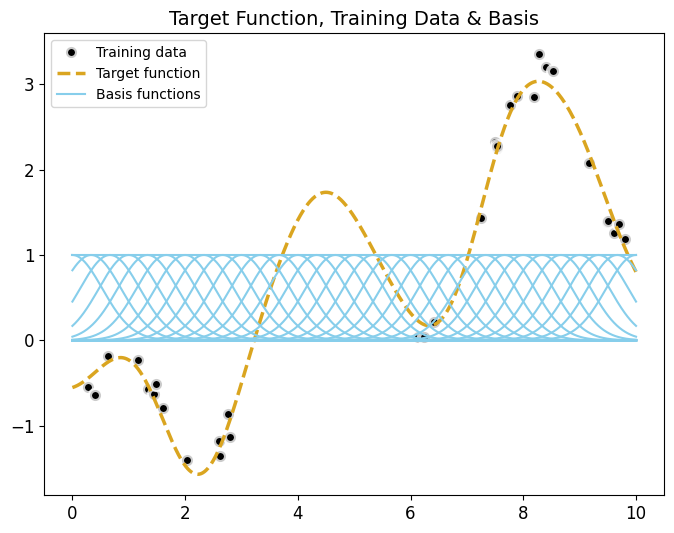

In [ ]:



# Define the number of training and validation data
N_train = len(x_train) # Number of samples in the training set
N_val = len(x_val)  # Number of samples in the validation set


# Define the radius of the model's basis functions
radius_model = radius_gen * 0.75


# Define the centers of the radial basis functions (RBF)
# Create N-1 centers uniformly distributed over the data range

centres = np.linspace(generator.x_min, generator.x_max, N_train - 1)
basis = setup.RBFGenerator(centres, width=radius_model, bias=True)



# Get the total number of basis functions used in the model
M = basis.M



# Compute the feature matrix (Phi) for each dataset

# If we call evaluate on the basis generator, we get an N x M matrix (Phi),
# where each row and column contains the output of each basis function at each data point.
# - Each column corresponds to a different basis function.
# - Each row corresponds to a data point.
# - The value at position Phi[n, m] is the result of evaluating the basis function phi_m at data point x_n.
# In short, the Phi matrix organizes the values ​​of the basis functions applied to the data,
# and the first column is always 1 for the bias.



PHI_train = basis.evaluate(x_train)
PHI_val = basis.evaluate(x_val)
PHI_test = basis.evaluate(x_test)



## display a summary of key values ​​in the terminal
# 
interest = ["N_train", "N_val", "N_test", "sigma", "sigma_2",
            "M", "radius_gen", "radius_model"]
setup.tabulate_locals(locals(), interest)






#   visualize the training data along with the basis functions and objective function
setup.plot_regression(x_train, y_train, x_test, y_test,  basis_test=PHI_test,
                      title="Target Function, Training Data & Basis", legend=True)



## Penalized Least Squares Regression

To begin the modeling process, we implement **penalized least squares (PLS)** regression, a foundational technique in Bayesian linear regression. This approach extends classical least squares by incorporating an $L_2$ regularization term, which penalizes large weights and helps prevent overfitting.

Given a design matrix $\Phi_{\text{train}}$ and corresponding target vector $y_{\text{train}}$, the goal is to estimate the optimal weight vector $\mathbf{w}_{\text{PLS}}$ that minimizes the following objective:




$$
E(\mathbf{w}) = \|\Phi_{\text{train}} \mathbf{w} - y_{\text{train}}\|^2 + \lambda \|\mathbf{w}\|^2
$$


Here, $\lambda$ is the **regularization parameter** that controls the trade-off between fitting the data and penalizing model complexity.

- When $\lambda = 0$, the solution reduces to the standard least squares estimate.
- For $\lambda > 0$, the solution becomes a ridge regression estimator, which has a closed-form expression involving the regularized inverse of the covariance matrix.

In the next step, we define a function to compute $\mathbf{w}_{\text{PLS}}$ for arbitrary values of $\lambda$ and evaluate how regularization influences the model’s behavior.

In [ ]:
## FIT_PLS
## What are we asked for? Fit a linear regression model using the PHI_train space as input and y_train as the actual outputs.
# The goal is to find the weights W that minimize the difference between the predictions and y_train.

def fit_pls(PHI, y, lam): 
     # lambda es el parámetro de regularización
    M = PHI.shape[1]  # Number of features (PHI columns)
    I = np.eye(M)     # Identity matrix for regularization

    # # Case without regularization (lambda = 0)
    if lam == 0:
        # # We use the standard solution without regularization
        w = np.linalg.lstsq(PHI, y, rcond=None)[0]  # rcond is the condition threshold
    
    # Case with regularization (lambda > 0)
    else:
        # use the closed formula for penalty #ridge regression
        w = np.linalg.inv(PHI.T @ PHI + lam * I) @ PHI.T @ y
    return w


SyntaxError: incomplete input (2154512403.py, line 6)


The function  `assess_predictor` 

- fits the model to the data for a given value of lambda using `fit_pls`
- computes the fitted model's predictions `f_test` on the *test set* (you will need to multiply the
  relevant $\mathbf{\Phi}$ by $\mathbf{w}_{PLS}$)
- plots the training data, target function (test data) and the predictions (using `plot_regression`)
- returns the RMS training and test errors




## Visualizing Regularization Effects in Penalized Models

To better understand how the regularization parameter $\lambda$ influences model complexity and generalization, we define a utility function that performs the full modeling pipeline:

1. Fits a penalized least squares (PLS) model for a given $\lambda$,
2. Uses the resulting weights to generate predictions over a test set,
3. Plots the training data, true target function, and model predictions,
4. Returns the root mean squared error (RMSE) for both training and test sets.

This allows us to systematically evaluate how different values of $\lambda$ affect both **fit quality** and **generalization**.

### Comparative Visualization

We apply this process for three different values of $\lambda$:

- **$\lambda = 1 \times 10^{-9}$**: Very weak regularization (expected to overfit),
- **$\lambda = 0.05$**: Moderate regularization (expected to generalize well),
- **$\lambda = 25$**: Strong regularization (expected to underfit).

Each model is trained on the same dataset, and the resulting predictions are visualized alongside the true underlying function. For each case, we also compute and report the RMSE on both training and test sets.

### Summary Table

The RMSE values are then summarized in a table, providing a quantitative measure of how each model performs. These results illustrate the classic **bias-variance tradeoff**, where:

- Small $\lambda$ values can lead to low bias but high variance (overfitting),
- Large $\lambda$ values produce smoother models with higher bias but reduced variance (underfitting),
- An intermediate $\lambda$ balances both effects for optimal generalization in observed regions.



In [ ]:
## FITTING & GRAPHING FUNCTION

def assess_predictor(basis, lamb, x_train, y_train, x_test, y_test):

    """
    Evaluated a regression model adjusted with regularization of Minimum Cuadras Parcial
    para un valor dado de lambda.



    -Adjust the model with fit_pls for a child.
    -Hace predictions in the proven data.
    -Calcula el error RMS en entrenamiento y prueba.
    -Graph the results with plot_regression.
    """


    # 1.  matrix

    
    PHI_train = basis.evaluate(x_train)
    PHI_test = basis.evaluate(x_test)

    # # 2. adjust the model
    w = fit_pls(PHI_train, y_train, lamb)

    # 3. prediction
    #The matrix product (or dot product in the case of vectors)
    # between the feature matrix PHI_test and the weight vector w.
    f_train = PHI_train @ w
    f_test = PHI_test @ w

    # 4. Errores RMS
    error_train = setup.error_rms(f_train, y_train)
    error_test = setup.error_rms(f_test, y_test)

    # 5.  graph
    setup.plot_regression(x_train, y_train, x_test, y_test, y_predict=f_test,
                    title=f"PLS Fit with λ = {lamb:.2e}")

    return error_train, error_test


In [ ]:


#### **** YOUR CODE HERE **** ####
"""
Model Visualization
compare:
Training data (black dots).
Generating function (yellow line).
Fitted model (red line).
This helps to see if there is overfitting or underfitting.

"""
#black dots training data
#solid red line model prediction
#golden line objective function

#The X axis represents the input values.
#The Y axis represents the output (actual or predicted value).

#Lambda values ​​to test
lambdas = [1e-9, 0.05, 25]

# Store errors
errors = []

## evaluate and graph
for lamb in lambdas:
    print(f"\nEvaluando para λ = {lamb:.2e}")
    error_train, error_test = assess_predictor(basis, lamb, x_train, y_train, x_test, y_test)
    errors.append((lamb, error_train, error_test))


In [ ]:

# Output your table here
#

#convert the error list to a DataFrame
df_errors = pd.DataFrame(errors, columns=['Lambda', 'Train RMS Error', 'Test RMS Error'])

# show table
print("RMS errors for different values ​​of lambda:")
print(df_errors)



## Bayesian Linear Regression: Posterior Inference

In the Bayesian treatment of linear regression, rather than finding a single best-fit weight vector, we **infer a posterior distribution over the weights** $\mathbf{w}$ given the observed data. This provides not only a point estimate (the posterior mean), but also a measure of uncertainty (the posterior covariance), enabling principled uncertainty-aware predictions.

Given a basis matrix $\Phi$, noise variance $\sigma^2$, and a prior precision $\alpha$ (equivalent to a regularization parameter), the posterior distribution over weights is Gaussian:

\[
p(\mathbf{w} \mid \mathbf{y}, \Phi, \alpha, \sigma^2) = \mathcal{N}(\mathbf{w} \mid \boldsymbol{\mu}, \boldsymbol{\Sigma})
\]

Where:


- The **posterior covariance** is:  
  $$
  \boldsymbol{\Sigma} = \left( \alpha \mathbf{I} + \frac{1}{\sigma^2} \Phi^\top \Phi \right)^{-1}
  $$

- And the **posterior mean** is:  
  $$
  \boldsymbol{\mu} = \frac{1}{\sigma^2} \boldsymbol{\Sigma} \Phi^\top \mathbf{y}
  $$



¿Quieres que sigamos con la reformulación del resto de Task 2 o pasamos a otra parte del notebook?
This formulation reflects the influence of both the data and the prior belief. Larger values of $\alpha$ imply stronger prior assumptions (more regularization), whereas lower values allow the data to dominate.

### Consistency Check with Penalized Least Squares

Note that penalized least squares (PLS) regression can be seen as a special case of Bayesian inference where only the posterior mean is considered. In fact, for a given value of $\lambda$, the equivalence between the Bayesian and frequentist formulations is:

$$
\alpha = \frac{\lambda}{\sigma^2}
$$

To verify this, we compute both:

- The weight vector $\mathbf{w}_{\text{PLS}}$ via penalized least squares, and  
- The posterior mean $\boldsymbol{\mu}$ from the Bayesian formulation.

The two results should match when $\alpha = \lambda / \sigma^2$. A quick numerical comparison confirms this consistency.




In [ ]:


def compute_posterior(PHI, y, alpha, sigma_squared):
    """
    Computes the mean and covariance of the posterior distribution in Bayesian regression.

    Parameters:
    - PHI: Feature matrix (N x M)
    - y: Vector of observed outputs (N x 1)

    - alpha: Regularization hyperparameter

    - sigma_squared: Noise variance (σ^2)

    Returns:
    - mu: Posterior mean (M x 1)

    - Sigma: Posterior covariance (M x M)
    """
    M = PHI.shape[1]  # Number of features
    I = np.eye(M)     # Identity matrix

    # 1. calculate the posterior covariance
    Sigma = np.linalg.inv(alpha * I + (1 / sigma_squared) * (PHI.T @ PHI))

    # 2.  calculate the posterior mean
    mu = (1 / sigma_squared) * (Sigma @ PHI.T @ y)

    return mu, Sigma



# check consistency
#
#### **** YOUR CODE HERE **** ####
#
#  parameters
lambda_value = 0.01  

 # Compute α from λ
alpha = lambda_value / sigma_2 



#  posterior calculation
Mu, Sigma = compute_posterior(PHI_train, y_train, alpha, sigma_2)

# penalized least squares calculation
w_pls = fit_pls(PHI_train, y_train, lambda_value)

# Consistency check

difference = np.linalg.norm(w_pls - Mu)

print(f"Consistency Check: Difference between PLS weights and Posterior Mean = {difference}")

w_pls_manual = np.linalg.solve(PHI_train.T @ PHI_train + lambda_value * np.eye(PHI_train.shape[1]), PHI_train.T @ y_train)
print(" difference between manual PLS and fit_pls :", np.linalg.norm(w_pls - w_pls_manual))  # Should be small

print(" computed lambda_value:", lambda_value)
print(" given lambda (should match computed lambda):", 0.01)
print("difference:", abs(lambda_value - 0.01))  # Should be close to 0
print("the first five values of w_pls :", w_pls[:5])

print(" first five values of mu:", Mu[:5])
print("element-wise difference:", w_pls[:5] - Mu[:5])



## Model Evidence: Computing the Marginal Likelihood

In Bayesian linear regression, the **marginal likelihood** (also known as the *model evidence*) measures how well a model with given hyperparameters $(\alpha, \sigma^2)$ explains the observed data $\mathbf{y}$. This quantity integrates out the model parameters and allows us to perform **model comparison** and **hyperparameter selection** in a principled way.

For a design matrix $\Phi$ with $N$ observations and $M$ basis functions, the marginal likelihood is given by:

$$
p(\mathbf{y} \mid \alpha, \sigma^2) = 
(2\pi)^{-\frac{N}{2}} 
\left| \sigma^2 \mathbf{I} + \alpha^{-1} \Phi \Phi^\top \right|^{-\frac{1}{2}} 
\exp\left\{ 
    -\frac{1}{2} \mathbf{y}^\top 
    \left( \sigma^2 \mathbf{I} + \alpha^{-1} \Phi \Phi^\top \right)^{-1} \mathbf{y} 
\right\}
$$

### Numerical Stability: Work in Log-Space

Because the marginal likelihood can span many orders of magnitude, we work with its logarithm to avoid numerical instability. The **log-marginal likelihood** becomes:

$$
\log p(\mathbf{y} \mid \alpha, \sigma^2) = 
-\frac{N}{2} \log(2\pi) 
- \frac{1}{2} \log \left| \sigma^2 \mathbf{I} + \alpha^{-1} \Phi \Phi^\top \right| 
- \frac{1}{2} \mathbf{y}^\top \left( \sigma^2 \mathbf{I} + \alpha^{-1} \Phi \Phi^\top \right)^{-1} \mathbf{y}
$$

To compute this, we define the function `compute_log_marginal`, which:

- Constructs the $N \times N$ covariance matrix of the marginal distribution:  
  $$
  \mathbf{C} = \sigma^2 \mathbf{I} + \alpha^{-1} \Phi \Phi^\top
  $$
- Uses `scipy.stats.multivariate_normal.logpdf` to compute the log-probability of $\mathbf{y}$ under the Gaussian $\mathcal{N}(0, \mathbf{C})`.

> **Important:** For stability, we always compute the log-marginal directly—**never compute the PDF and then apply `np.log`**. Doing so can cause severe numerical underflow.

---

### Optional: Woodbury Identity for Efficient Marginal Likelihood

Although the standard computation is reliable for small datasets, it involves inverting and computing the determinant of an $N \times N$ matrix, which becomes expensive and numerically sensitive when $N$ is large.

Using the **Woodbury identity**, we can rephrase the computation in terms of an $M \times M$ matrix, which is computationally cheaper and more robust when $M \ll N$. The identity is:

$$
(A + UCV)^{-1} = A^{-1} - A^{-1} U (C^{-1} + V A^{-1} U)^{-1} V A^{-1}
$$

In our context:

$$
A = \sigma^2 \mathbf{I}, \quad U = \Phi, \quad C = \alpha^{-1} \mathbf{I}, \quad V = \Phi^\top
$$

This allows us to compute:

- $\log |\mathbf{C}|$ in terms of $\log |\mathbf{A}|$ and a smaller determinant,
- $\mathbf{C}^{-1} \mathbf{y}$ using a formula that avoids inverting $\mathbf{C}$ directly.

While in this coursework $N = M$, in real-world applications where $N \gg M$, the computational savings are significant.


In [ ]:

## MARGINAL LIKELIHOOD
##
def compute_log_marginal(PHI, y, alpha, sigma_squared):
    """
    Computes the log-likelihood of the marginal likelihood for Bayesian regression.

    Parameters:
    - PHI: Feature matrix (N x M).
    - y: Vector of observed outputs (N x 1).
    - alpha: Regularization hyperparameter.
    - sigma_squared: Noise variance (σ^2).

    Returns:
    - log_marginal (float): Log-likelihood of the marginal likelihood.
    """

    # 1. Number of data (N)
    N = PHI.shape[0]

    # 2. Identity matrix of size N x N
    I_N = np.eye(N)

    # 3. Calculate the covariance matrix C_N
    C_N = sigma_squared * I_N + (1 / alpha) * (PHI @ PHI.T)

    # 4. Flatten and to ensure it is a one-dimensional vector


    y = np.squeeze(y, axis=1)

    # 5.Calculate the log of the marginal likelihood
    log_marginal = multivariate_normal.logpdf(y, mean=np.zeros(N), cov=C_N)


    # 6.  Convert to scalar (float) and return
    return log_marginal

In [ ]:
## MARGINAL LIKELIHOOD (ADVANCED VERSION - OPTIONAL)
##
def compute_log_marginal_advanced(PHI, y, alph, s2):
    #
    #### **** YOUR CODE HERE **** ####
    #



## Model Selection: Exploring Regularization via Marginal Likelihood and Error Curves

To evaluate and select an appropriate regularization strength $\lambda$ in Bayesian linear regression, we analyze how different values of $\lambda$ (and their corresponding $\alpha = \lambda / \sigma^2$) affect model performance and marginal likelihood.

This section reproduces the key idea from the lecture: **Occam’s Razor in Bayesian modelling** — balancing model fit and complexity to avoid both underfitting and overfitting.

---

### Procedure

Over a logarithmic range of $\lambda$ values (from $10^{-6}$ to $10^{4}$), the following quantities are computed:


- **Training error**, **validation error**, and **test error** using penalized least squares (`fit_pls`) and RMS error (`error_rms`),
- **Negative log marginal likelihood**:
  - On the training set,
  - On the combined training + validation set.

This results in four curves, each plotted as a function of $\lambda$. Since the marginal likelihood is a log-probability and the errors are squared distances, they use **different vertical axes**. Therefore, the plot includes two y-axes for clarity.

---

### Plot and Interpretation

The plot illustrates how:

- **Training error** consistently decreases as $\lambda \rightarrow 0$ (overfitting region),
- **Validation and test errors** follow a U-shaped curve, reflecting the optimal trade-off point,
- **Marginal likelihood** curves (especially on combined data) peak near the ideal model complexity — consistent with Bayesian Occam’s Razor.

This comparison helps validate the marginal likelihood as a principled metric for **automated model selection**, especially when no test data is available.

---

### Optimal $\alpha$ and Model Evaluation

From the curves, we extract and report the test errors at the points where:

- Test error is minimized,
- Validation error is minimized,
- Negative log marginal likelihood (on training set) is minimized,
- Negative log marginal likelihood (on combined training and validation sets) is minimized.

Finally, the **best $\alpha$** is defined as the one that minimizes the negative log marginal likelihood on the combined dataset. This $\alpha$ value is often used as a default for posterior inference and prediction in Bayesian pipelines.

---

### Notes on Implementation

- The $\lambda$ values are sampled in logarithmic space using `np.logspace(-6, 4, 100)`.
- The marginal likelihood computation uses the `compute_log_marginal` function.
- To plot curves with dual y-axes, we use `plt.gca().twinx()` for overlaying metrics with different scales.
- Correct alignment between $\lambda$ and $\alpha$ is essential:  
  \[
  \alpha = \frac{\lambda}{\sigma^2}
  \]



In [ ]:
# set the values ​​of λ in logarithmic scale
lambda_values = np.logspace(-6, 4, 100)  # 100 values ​​between 10^-6 and 10^4
alpha_values = lambda_values / sigma_2   # Convert to α using sigma^2

# lists to store results
train_errors = []  # RMS errors in training
val_errors = []    # RMS errors in validation
test_errors = []   # RMS errors in test
log_marginals_train = []       # Marginal log-likelihood in train
log_marginals_train_val = []   # Marginal log-likelihood in train + val

# Iterate over each value of λ to evaluate the model
for lam, alpha in zip(lambda_values, alpha_values):
    # Adjust model with Penalized Least Squares (PLS)
    w = fit_pls(PHI_train, y_train, lam)  # The model is adjusted to obtain the optimal weights

    # Make predictions on train, val and test
    f_train = PHI_train @ w  
    f_val = PHI_val @ w      #validations
    f_test = PHI_test @ w    
    
    #   Calculate RMS errors and store
    train_errors.append(setup.error_rms(f_train, y_train))  
    val_errors.append(setup.error_rms(f_val, y_val))        
    test_errors.append(setup.error_rms(f_test, y_test))     

    ## Compute the negative marginal log-likelihood on the training set
    log_marginals_train.append(compute_log_marginal(PHI_train, y_train, alpha, sigma_2))

    # Calculate marginal log-likelihood for combined data (train + validation)
    PHI_combined = np.vstack((PHI_train, PHI_val))  # Join feature matrices
    y_combined = np.vstack((y_train, y_val))        # Merge training and validation labels

    log_marginals_train_val.append(compute_log_marginal(PHI_combined, y_combined, alpha, sigma_2))

# Find the optimal values ​​of λ and α
best_lambda_test = lambda_values[np.argmin(test_errors)]   # Mejor λ para Test (mínimo error RMS)
best_lambda_val = lambda_values[np.argmin(val_errors)]     # Mejor λ para Validation (mínimo error RMS)
best_lambda = lambda_values[np.argmax(log_marginals_train_val)]  # Mejor α basado en verosimilitud marginal
best_train = log_marginals_train[np.argmax(log_marginals_train)] # Mejor λ basado en verosimilitud marginal en training

# Plot the results
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xscale("log")  # Log scale on X axis to better visualize the variation of λ
ax1.set_ylim(0, 1)  # Set the RMS error Y axis between 0 and 1

# plot RMS errors for training, validation and testing

train_line, = ax1.plot(lambda_values, train_errors, label="Train Error", linestyle="dashed", color="darkred", linewidth=2)
val_line, = ax1.plot(lambda_values, val_errors, label="Validation Error", linestyle="solid", color="blue", linewidth=2)
test_line, = ax1.plot(lambda_values, test_errors, label="Test Error", linestyle="solid", color="goldenrod", linewidth=2)

# highlight optimal values ​​on the graph

best_test = ax1.scatter(best_lambda_test, min(test_errors), color="gold", edgecolor="black", s=100, label="Best λ (Test)")
best_val = ax1.scatter(best_lambda_val, min(val_errors), color="blue", edgecolor="black", s=100, label="Best λ (Validation)")

# Second Y axis for negative marginal likelihood
ax2 = ax1.twinx()
log_train, = ax2.plot(lambda_values, -np.array(log_marginals_train), label="-log p(t | α, σ²) (Train)", linestyle="dashed", color="black", linewidth=2)
log_train_val, = ax2.plot(lambda_values, -np.array(log_marginals_train_val), label="-log p(t | α, σ²) (Train+Val)", linestyle="solid", color="black", linewidth=2)

# highlight better α based on marginal likelihood

best_alpha = ax2.scatter(lambda_values[np.argmax(log_marginals_train_val)], -max(log_marginals_train_val), color="red", edgecolor="black", s=100, label="Best α")

#  labes
ax1.set_ylabel("RMS Error")  
ax1.set_xlabel("log λ")      
ax2.set_ylabel("- log p(t | α, σ²)", color="red")

#  merge all legends into one Labels
handles = [train_line, val_line, test_line, best_test, best_val, log_train, log_train_val, best_alpha]
labels = [h.get_label() for h in handles]
ax1.legend(handles, labels, loc="upper left")  

plt.title("Model Complexity vs. Performance")  

table_data = [
    ["Best λ (Test)", f"{best_lambda_test:.2e}"],
    ["Best λ (Validation)", f"{best_lambda_val:.2e}"],
    ["Best λ (Likelihood training)", f"{best_train:.2e}"],
    ["Best α (Marginal Likelihood)", f"{best_lambda:.2e}"]
]

table = plt.table(cellText=table_data,
                  colLabels=["Metric", "Value"],
                  cellLoc="center",
                  loc="bottom",
                  bbox=[0.2, -0.45, 0.6, 0.2])  # Adjust table position


plt.show()

In [ ]:
# PLEASE PLOT ALL THE CURVES IN THE SAME FIGURE

# Print out (or tabulate) the test error corresponds to the minimum point on (1) the test error curve itself,
# (2) the validation curve, and (3, 4) the negative marginal-likelihood curves.
#
#### **** YOUR PLOTTING CODE HERE **** ####
#




## Posterior Mean Prediction and Final Model Evaluation

Once the optimal regularization level $\alpha$ has been identified using the marginal likelihood on combined training and validation data, we can evaluate the **posterior mean predictor** of the Bayesian linear regression model.

---

### Posterior Mean Predictor

Using the function `compute_posterior`, we compute the **posterior mean vector** $\boldsymbol{\mu}$:

$$
\boldsymbol{\mu} = \frac{1}{\sigma^2} \boldsymbol{\Sigma} \Phi^\top \mathbf{y}
$$

This vector represents the mean of the posterior distribution over the model weights $\mathbf{w}$. It captures the most likely configuration of the model under the Bayesian framework, accounting for both the observed data and the prior.

We then use $\boldsymbol{\mu}$ to compute the **predictive mean** at the test inputs `x_test`:


$$
f_{\text{test}} = \Phi_{\text{test}} \boldsymbol{\mu}
$$


### Visualization

To assess the model’s fit visually, we generate a plot showing:

1. **Training data points** — the noisy observations used for model fitting.
2. **True underlying function** — the ground-truth values at test locations (`y_test`).
3. **Posterior mean predictions** — the model’s estimated output over the test domain.

This plot highlights how well the model captures the structure of the data where it has observed training points. Importantly, it also shows increased uncertainty or deviation in regions where **no training data was provided** — illustrating a key strength of Bayesian models: recognizing their own limits.

---

### Insight

In regions where training data is dense, the posterior mean closely follows the true function. However, in the **unobserved gap**, the model tends to revert to a smoother prior-driven behavior — a desirable trait for uncertainty-aware systems.

This step concludes the modelling pipeline by confirming that the selected $\alpha$ (based on marginal likelihood) not only minimizes generalization error but also yields predictions consistent with the known data-generating process.



In [ ]:
# Code to calculate posterior mean weights and corresponding predictor
#### **** YOUR CODE HERE **** ####


In [ ]:
# Visualise the predictor
#
#### **** YOUR PLOTTING CODE HERE **** ####
#



## Decision-Aware Predictions: When to Predict and When to Abstain

In real-world applications, the cost of making an incorrect prediction can outweigh the benefit of being accurate. One advantage of Bayesian models is that they not only provide predictions, but also quantify their **confidence** through predictive uncertainty. This section explores how to leverage that uncertainty in **risk-sensitive decision-making**.

---

### Problem Setup

We assume the trained Bayesian model is deployed in a system where:

- The true outputs are **noiseless**.
- Predictions at $x_*$ come from a **Gaussian predictive distribution** with mean $\mathbb{E}[y_*]$ and variance $\mathbb{V}[y_*]$.
- For each prediction:
  - If the absolute error is $\leq \texttt{threshold} = 0.15$, a reward of **£10** is earned.
  - If the error exceeds the threshold, a cost of **£20** is incurred.
  - Crucially, **we are allowed to abstain from predicting**, incurring no cost and no reward.

This setup mirrors many real-world environments (e.g., finance, healthcare, safety-critical systems) where it is preferable to remain silent unless confident.

---

### Strategy: Risk-Aware Expected Utility

We design a **decision rule** to choose whether or not to predict at a given input $x$, based only on:

- The model’s predictive **mean** and **variance** at that $x$.
- The **expected utility** under the Gaussian predictive distribution.

Let $f(x)$ be the predictive mean and $s(x)$ the predictive standard deviation. We define the **expected reward** as the expected value of:

- £10 if the absolute error is within the threshold,
- -£20 otherwise.

Since the model predicts $y \sim \mathcal{N}(f(x), s(x)^2)$, the probability of success is:

$$
P(|y - f(x)| \leq \text{threshold}) = \Phi\left( \frac{\text{threshold}}{s(x)} \right) - \Phi\left( -\frac{\text{threshold}}{s(x)} \right)
$$

Where $\Phi$ is the standard normal CDF.

Thus, the **expected gain** at $x$ is:

$$
\text{Earnings}(x) = 10 \cdot P_{\text{win}} - 20 \cdot (1 - P_{\text{win}})
$$

We choose to predict **only if** $\text{Earnings}(x) > 0$.

This rule allows the model to abstain in areas of high uncertainty and to act only where its confidence justifies the risk.

---

### Summary of Implementation

1. **Calculate predictive standard deviation** at each $x_{\text{test}}$.
2. **Compute expected reward** at each point using the predictive standard deviation and Gaussian CDF.
3. **Decide to predict** only if expected earnings are positive.
4. **Evaluate outcomes**: count predictions, rewards, penalties, and compute total earnings.
5. **Visualize** decisions, predictions, and uncertainty.



In [ ]:

# Compute the predictive variance
#
#### **** YOUR CODE HERE **** ####


# 1. Calculate the mean and covariance of the posterior distribution
mu_posterior, Sigma_posterior = compute_posterior(PHI_train, y_train, best_lambda, sigma_2)

# 2. Calculate the predictive variance
PHI_test = basis.evaluate(x_test)
variance_pred = sigma_2 + np.sum(PHI_test @ Sigma_posterior * PHI_test, axis=1)

#print('variance_pred', variance_pred)
# 3. Convert to standard deviation to graph ±1 sigma
std_pred = np.sqrt(variance_pred).ravel()
f_test_posterior = (PHI_test @ mu_posterior).ravel()
x_test = x_test.ravel()  # Ensure that x_test is also 1D


In [ ]:
# Plot the error bars
#
#### **** YOUR PLOTTING CODE HERE **** ####
# 4. Plotting Bayesian regression with error bars
plt.figure(figsize=(10, 6))
plt.plot(x_test, y_test, linestyle="--", color="goldenrod", label="Target Function")
plt.plot(x_test, f_test_posterior, color="red", label="Bayesian Predictor")

# uncertainty band (±1 standard deviation)
plt.fill_between(x_test, 
                 f_test_posterior - std_pred,
                 f_test_posterior + std_pred,
                 color="lightblue", alpha=0.5, label="Predictive Uncertainty")

# plot the training points
plt.scatter(x_train, y_train, color="black", label="Training Data")

plt.title("Bayesian Regression with Predictive Uncertainty")
plt.legend()
plt.show()

# 5. implement decision strategy !
threshold = 0.15
reward_under = 10
cost_above = 20

# initialize counters
num_predictions = 0
num_rewards = 0
num_costs = 0
total_earnings = 0
decisions = []

# strategy: Only predict if uncertainty is less than threshold
for i in range(len(x_test)):
    pred = f_test_posterior[i]
    true_val = y_test[i]
    uncertainty = std_pred[i]

    if uncertainty < threshold:  # predict only if uncertainty is low
        num_predictions += 1
        error = abs(pred - true_val)

        if error <= threshold:
            num_rewards += 1
            total_earnings += reward_under
        else:
            num_costs += 1


## Task 3b
*5 marks overall*

This is a more open-ended question, with an opportunity to think a little creatively.

Imagine you had built the above model for inclusion within some real-world system where 
it was desired to make accurate predictions at the 1,000 test points. For this exercise, you
can assume there is no data noise when deployed, and the only predictive uncertainty is due
to the weights of the trained model.

The "real-world system" is such that there are costs and rewards associated with each prediction:

- for each absolute error of `threshold=0.15` or less, the model is rewarded with £10
- for each absolute error of greater than `threshold`, there is a cost of £20

**Key feature of the "system":** *You may decline to make a prediction for a given data point*, based on the knowledge of $x$.
If you do decline to make a prediction, there is no cost (or reward).

### Devise an Algorithm Which Chooses When to Predict (and When to Decline)
*Without knowledge of the test set*, devise an algorithm that aims to maximise your *expected* earnings.
That is, an algorithm that decides, given an arbitrary $x$, whether to predict $y$ or whether to decline.
This can only be an approximate maximisation (remember, "all models are wrong"), but, given the model,
there is a principled way to make a decision whether to predict or decline, given the cost and reward
specification.

Specifically, where indicated in the below cells (and detailed further below), do the following four things:

1. Explain your approach
2. Implement your algorithm
3. Evaluate it and tabulate results
4. **Advanced:** Visualise its decision-making

#### Explain your algorithm (2 marks)

Write a short explanation of your approach in the "Explanation of Approach" markdown cell.

#### Implement your algorithm (1 mark)

Provide the necessary decision code for your algorithm in the first code cell below.

#### Evaluate your approach and tabulate some statistics (1 mark)

In the second code cell below, apply your algorithm to the 1,000 (noiseless) test points `x_test` and tabulate:

- The number of predictions (out of 1,000) made
- The number that were rewarded for being within threshold
- The number that were charged for being outside the threshold
- The percentage of predictions made that were rewarded
- Your total earnings

You should be able to make as much as £5,000 (or thereabouts, without cheating!).
If your algorithm is over-confident and makes too many predictions, you may do poorly due to incurring many costs. Alternatively, if your algorithm is too conservative and declines to predict too often, you may do poorly due to not earning enough rewards.

#### Visualise the operation of your algorithm (advanced) (1 mark)

**Advanced:** Plot a graph which illustrates where your algorithm chooses to predict and where it chooses to decline.
More specifically, you should show:
- the target function (test points `x_test` and `y_test` as a line)
- your predictor (posterior mean)
- the error-bars, but only where the algorithm chooses to predict, and in one particular colour of your choosing
- the error-bars, this time only where the algorithm chooses to decline, and in a different colour of your choosing
- a helpful legend
- Optionally: the training data


### Explanation of Approach (*Your Answer Here*)

*Explain your approach and algorithm here in this cell (and delete this text)*



In [ ]:
# Implement your algorithm here
#
# Use these fixed values
threshold = 0.15
reward_under = 10
cost_above = 20

#### **** YOUR ALGORITHM CODE HERE **** ####


In [ ]:


# dynamic adjustment of the marginal likelihood threshold

log_marginals = [compute_log_marginal(PHI_test[i:i+1], y_test[i:i+1], best_lambda, sigma_2) for i in range(len(f_test_posterior))]
threshold_marginal = np.percentile(log_marginals, 25)  # Usar el percentil 25 como referencia

# algorithm based on marginal likelihood

def decision_with_marginal_likelihood(PHI_test, y_test, f_test_posterior, std_pred, alpha, sigma_2, threshold, reward_under, cost_above, threshold_marginal):
    num_predictions = 0
    num_rewards = 0
    num_costs = 0
    total_earnings = 0
    accepted_indices = []
    declined_indices = []
    
    for i in range(len(f_test_posterior)):
        log_marginal = compute_log_marginal(PHI_test[i:i+1], y_test[i:i+1], alpha, sigma_2)
        
        # dynamic adjustment of the uncertainty threshold
        adaptive_threshold = threshold * (1 + np.exp(-std_pred[i]) / np.std(std_pred) + 0.1)
        
        #if the marginal likelihood is high and the uncertainty is low, the prediction is made
        if log_marginal > threshold_marginal and std_pred[i] < adaptive_threshold:
            num_predictions += 1
            accepted_indices.append(i)
            
            error = abs(f_test_posterior[i] - y_test[i])
            if error <= threshold:
                num_rewards += 1
                total_earnings += reward_under
            else:
                num_costs += 1
                total_earnings -= cost_above
        else:
            declined_indices.append(i)
    
    return num_predictions, num_rewards, num_costs, total_earnings, accepted_indices, declined_indices

#  implementation of the strategy
num_predictions, num_rewards, num_costs, total_earnings, accepted, declined = decision_with_marginal_likelihood(
    PHI_test, y_test, f_test_posterior, std_pred, best_lambda, sigma_2, threshold, reward_under, cost_above, threshold_marginal
)

# Show results
print(f"Total number of predictions made: {num_predictions}")
print(f"Umbral Prediction Number: {num_rewards}")
print(f"Number of predictions outside the threshold: {num_costs}")
if num_predictions > 0:
 print(f"Percentage of exiting predictions: {num_rewards / num_predictions * 100:.2f}%")
else:
 print("Percentage of exiting predictions: No predictions will be made")
print(f"Total earnings: £{total_earnings}")

#Strategy visualization
def plot_marginal_decision(x_test, y_test, f_test_posterior, std_pred, accepted, declined):
    plt.figure(figsize=(10, 6))
    plt.plot(x_test, y_test, linestyle="--", color="goldenrod", label="Target Function")
    plt.plot(x_test, f_test_posterior, color="red", label="Bayesian Predictor")
    
    if accepted:
        plt.fill_between(x_test[accepted], 
                         f_test_posterior[accepted] - std_pred[accepted],
                         f_test_posterior[accepted] + std_pred[accepted],
                         color="lightgreen", alpha=0.5, label="Accepted Predictions")
    
    if declined:

        plt.fill_between(x_test[declined], 
                         f_test_posterior[declined] - std_pred[declined],
                         f_test_posterior[declined] + std_pred[declined],
                         color="lightcoral", alpha=0.5, label="Declined Predictions")
    
    plt.scatter(x_train, y_train, color="black", label="Training Data")
    plt.title("Marginal Likelihood Decision Strategy")
    plt.legend()
    plt.show()

# graph the applied strategy
plot_marginal_decision(x_test, y_test, f_test_posterior, std_pred, accepted, declined)

# visualize distribution of marginal similarity
plt.hist(log_marginals, bins=30)
plt.title("Marginal Likelihood Distribution")
plt.xlabel("Log Marginal Likelihood")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Visualise your algorithm's decision-making (advanced / optional)

#### **** YOUR GRAPHING CODE HERE **** ####
#
